# Florence-2 Fine-Tuning on 8,125 NSSF Documents
### HuggingFace `Trainer` + LoRA + Gradient Checkpointing
**Platform**: RunPod (or any single-GPU instance)  
**Dataset**: `ultimate_training_dataset.json` — 8,125 entries, no reformatting needed  
**Task token**: `<Extract_NSSF_Data>` → structured JSON (mixed print + handwriting, tables, forms)

---
### ⚠ 8 bugs fixed from the original snippet — read before running
| # | Bug | Fix |
|---|-----|-----|
| 1 | Full 365-token Qwen prompt fed to Florence (context overflow) | Strip → replace with `<Extract_NSSF_Data>` |
| 2 | `processor()` call has no `max_length` | Add `max_length=512, truncation=True` |
| 3 | LoRA `r=8 alpha=8` → scale=1.0 (underpowered for handwriting) | `r=16, alpha=32` (scale=2.0) |
| 4 | `max_steps=1000` = only 0.98 epochs on 8,125 samples | Use `num_train_epochs=5` |
| 5 | `gradient_checkpointing=True` missing from `TrainingArguments` | Added |
| 6 | `model.config.use_cache = False` missing (crashes with grad-checkpointing) | Added |
| 7 | `model.resize_token_embeddings()` missing after adding task token | Added |
| 8 | Image path not prefixed with `BASE_DIR` (fails on RunPod `/workspace`) | Fixed |


## 0. Install Dependencies

In [1]:
# ── Disable hf_transfer fast download (env var set by RunPod but package
# may not be installed yet — causes ValueError before anything runs) ────────
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'

import subprocess, sys, os

subprocess.run('pip config set global.root-user-action ignore', shell=True, capture_output=True)

# ── Step 1: Upgrade PyTorch for Blackwell GPU (sm_120 / RTX PRO 4500) ────────
# RTX PRO 4500 (Blackwell, sm_120) requires PyTorch ≥ 2.7.0 built with CUDA 12.8.
# The default RunPod image ships with PyTorch 2.x + CUDA 11.x/12.x which only
# supports up to sm_90 (Hopper). Running on Blackwell with an old wheel gives:
#   "CUDA error: no kernel image is available for execution on the device"
# We uninstall the old torch stack first, then pull the CUDA 12.8 wheels.
print('Upgrading PyTorch for Blackwell sm_120 support…')
subprocess.run(
    [sys.executable, '-m', 'pip', 'uninstall', '-y', 'torch', 'torchvision', 'torchaudio'],
    capture_output=True
)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--root-user-action=ignore',
     'torch>=2.7.0', 'torchvision', 'torchaudio',
     '--index-url', 'https://download.pytorch.org/whl/cu128',
    ],
    check=True
)
# Quick sanity check
import importlib
torch = importlib.import_module('torch')
print(f'✅ PyTorch {torch.__version__}  |  CUDA {torch.version.cuda}')
cap = torch.cuda.get_device_capability()
print(f'   GPU capability: sm_{cap[0]}{cap[1]}  (need sm_120 for Blackwell)')

# ── Step 2: Fix typing_extensions / pydantic-core conflict ───────────────────
# wandb ≥ 0.18 → pydantic ≥ 2.12 → pydantic-core → needs typing_extensions ≥ 4.12.0
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--root-user-action=ignore',
     'typing_extensions', 'pydantic>=2.0', 'pydantic-core>=2.0',
    ],
    check=True
)
print('✅ typing_extensions / pydantic upgraded')

# ── Step 3: Install everything else ──────────────────────────────────────────
pkgs = [
    'transformers==4.49.0',
    'peft>=0.10.0',
    'accelerate>=0.27.0',
    'bitsandbytes>=0.43.0',
    'einops', 'timm', 'sentencepiece', 'protobuf',
    'rapidfuzz', 'pillow', 'tqdm',
    'opencv-python-headless',
    'wandb',
    'matplotlib',
    'gdown',
    'py7zr',
]
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--root-user-action=ignore'] + pkgs,
    check=True
)
print('✅ All dependencies installed')
print()
print('⚠  IMPORTANT: Kernel restart required after this cell.')
print('   Kernel → Restart Kernel, then run from cell 2 onwards.')
print('   (The old torch is cached in memory until restart.)')


Upgrading PyTorch for Blackwell sm_120 support…
✅ PyTorch 2.10.0+cu128  |  CUDA 12.8
   GPU capability: sm_120  (need sm_120 for Blackwell)
✅ typing_extensions / pydantic upgraded
✅ All dependencies installed

⚠  IMPORTANT: Kernel restart required after this cell.
   Kernel → Restart Kernel, then run from cell 2 onwards.
   (The old torch is cached in memory until restart.)


## 0b. Download & Extract Data from Google Drive

In [2]:
import os, shutil
import gdown

# ── Google Drive file IDs ──────────────────────────────────────────────────
# nssf_dataset.7z  — the 8,125-image training set
# custom_nssf_model.7z — your previously trained 87-sample Florence model
DATASET_FILE_ID = '1WMF_rIQ3nAJfFNqaNNXbDM0GOMLSZhvP'
MODEL_FILE_ID   = '1GvkoqBX9aS3sxPM7nsO5YFVbb9-ML50m'

# ── Destination paths ─────────────────────────────────────────────────────
# Hard-coded to /workspace here because this cell runs before the config
# cell sets BASE_DIR — avoids a NameError if cells are run out of order.
_base = '/workspace' if os.path.exists('/workspace') else os.path.expanduser('~')

downloads = {
    DATASET_FILE_ID: os.path.join(_base, 'nssf_dataset.7z'),
    MODEL_FILE_ID:   os.path.join(_base, 'custom_nssf_model.7z'),
}

for fid, dest in downloads.items():
    if not fid:
        print(f'⚠  File ID empty — skipping {os.path.basename(dest)}')
        continue
    if os.path.exists(dest):
        size_gb = os.path.getsize(dest) / 1e9
        print(f'✅ Already downloaded: {os.path.basename(dest)} ({size_gb:.2f} GB) — skipping')
        continue
    print(f'Downloading {os.path.basename(dest)} from Google Drive…')
    gdown.download(f'https://drive.google.com/uc?id={fid}', dest, quiet=False)
    size_gb = os.path.getsize(dest) / 1e9
    print(f'✅ Saved: {dest} ({size_gb:.2f} GB)')

print('\nDownload step complete ✅')


✅ Already downloaded: nssf_dataset.7z (4.05 GB) — skipping
✅ Already downloaded: custom_nssf_model.7z (0.73 GB) — skipping

Download step complete ✅


In [3]:
import zipfile, tarfile

def smart_extract(archive_path, dest_folder):
    """
    Extracts .7z / .zip / .tar.gz into dest_folder.
    Detects actual format by magic bytes — never trusts the file extension.
    Always extracts INTO dest_folder (never dumps files into the parent dir).
    """
    if not os.path.exists(archive_path):
        print(f'⚠  Not found: {archive_path}')
        return False

    os.makedirs(dest_folder, exist_ok=True)
    size_mb = os.path.getsize(archive_path) / 1e6

    with open(archive_path, 'rb') as f:
        magic = f.read(8)

    is_7z  = magic[:6] == b'7z\xbc\xaf\x27\x1c'
    is_zip = magic[:2] == b'PK'
    is_tar = magic[:2] == b'\x1f\x8b'

    print(f'Extracting {os.path.basename(archive_path)} ({size_mb:.0f} MB) → {dest_folder}')

    if is_7z:
        print('  Format: 7z')
        try:
            import py7zr
            with py7zr.SevenZipFile(archive_path, mode='r') as z:
                z.extractall(path=dest_folder)
            return True
        except Exception as e:
            print(f'  py7zr failed: {e}')
            return False

    elif is_zip:
        print('  Format: zip')
        with zipfile.ZipFile(archive_path, 'r') as z:
            members   = z.namelist()
            top_levels = set(m.split('/')[0] for m in members if m.strip('/'))
            has_wrapper = (len(top_levels) == 1 and
                           any(m.endswith('/') for m in members))
            if has_wrapper:
                parent = os.path.dirname(dest_folder)
                z.extractall(parent)
                inner = os.path.join(parent, list(top_levels)[0])
                if inner != dest_folder and os.path.exists(inner):
                    os.rename(inner, dest_folder)
            else:
                z.extractall(dest_folder)
        return True

    elif is_tar:
        print('  Format: tar.gz')
        with tarfile.open(archive_path, 'r:gz') as t:
            t.extractall(dest_folder)
        return True

    else:
        print(f'  Unknown format (magic: {magic[:6].hex()}) — trying zip…')
        try:
            with zipfile.ZipFile(archive_path, 'r') as z:
                z.extractall(dest_folder)
            return True
        except Exception as e:
            print(f'  Failed: {e}')
            return False


_base         = '/workspace' if os.path.exists('/workspace') else os.path.expanduser('~')
img_exts      = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

# ── Extract dataset ────────────────────────────────────────────────────────
DATASET_DIR     = os.path.join(_base, 'nssf_dataset')
DATASET_ARCHIVE = os.path.join(_base, 'nssf_dataset.7z')

if os.path.exists(DATASET_DIR) and len(os.listdir(DATASET_DIR)) > 0:
    imgs = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(img_exts)]
    # Dataset uses a double-nested structure: nssf_dataset/nssf_dataset/*.jpg
    # A flat listdir() on the outer folder returns 0 — check one level deeper.
    if not imgs:
        inner = os.path.join(DATASET_DIR, 'nssf_dataset')
        if os.path.exists(inner):
            imgs = [f for f in os.listdir(inner) if f.lower().endswith(img_exts)]
    print(f'✅ Dataset already extracted: {DATASET_DIR}')
    print(f'   {len(imgs)} images found')
else:
    ok = smart_extract(DATASET_ARCHIVE, DATASET_DIR)
    if ok:
        imgs = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(img_exts)]
        if not imgs:
            inner = os.path.join(DATASET_DIR, 'nssf_dataset')
            if os.path.exists(inner):
                imgs = [f for f in os.listdir(inner) if f.lower().endswith(img_exts)]
        print(f'✅ Extracted — {len(imgs)} images in {DATASET_DIR}')
    else:
        print('❌ Dataset extraction failed — check the archive')

# ── Extract custom Florence model ─────────────────────────────────────────
MODEL_DIR     = os.path.join(_base, 'custom_nssf_model')
MODEL_ARCHIVE = os.path.join(_base, 'custom_nssf_model.7z')

if os.path.exists(MODEL_DIR) and len(os.listdir(MODEL_DIR)) > 0:
    mfiles = os.listdir(MODEL_DIR)
    print(f'\n✅ Custom model already extracted: {MODEL_DIR}')
    print(f'   {len(mfiles)} files: {mfiles[:6]}')
else:
    ok = smart_extract(MODEL_ARCHIVE, MODEL_DIR)
    if ok:
        mfiles = os.listdir(MODEL_DIR)
        print(f'\n✅ Model extracted — {len(mfiles)} files in {MODEL_DIR}')
        print(f'   Contents: {mfiles[:8]}')
    else:
        print('\n⚠  Model extraction skipped or failed')
        print('   This notebook fine-tunes from Florence-2-large-ft — custom model not required')

print('\n✅ Extraction step complete')


✅ Dataset already extracted: /workspace/nssf_dataset
   11820 images found

✅ Custom model already extracted: /workspace/custom_nssf_model
   10 files: ['tokenizer.json', 'added_tokens.json', 'model.safetensors', 'tokenizer_config.json', 'config.json', 'merges.txt']

✅ Extraction step complete


## 1. Imports & Device

In [4]:
import os, gc, json, time, math, random, re
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'  # prevent hf_transfer crash if package not yet installed

import numpy as np
import torch
import wandb
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    cap  = torch.cuda.get_device_capability()
    print(f'VRAM   : {vram:.1f} GB')
    print(f'Compute: sm_{cap[0]}{cap[1]}')
    if vram < 20:
        print('⚡ T4 (16 GB)          → large model: BATCH_SIZE=1, GRAD_ACCUM=8')
    elif vram < 30:
        print('⚡ A10/RTX4090 (24 GB) → large model: BATCH_SIZE=2, GRAD_ACCUM=4')
    elif vram < 40:
        print('⚡ RTX PRO 4500 (34 GB) → large model: BATCH_SIZE=4, GRAD_ACCUM=2')
    else:
        print('⚡ A100/A40 (40+ GB)   → large model: BATCH_SIZE=4, GRAD_ACCUM=2')


Device : cuda
GPU    : NVIDIA GeForce RTX 5090
VRAM   : 33.7 GB
Compute: sm_120
⚡ RTX PRO 4500 (34 GB) → large model: BATCH_SIZE=4, GRAD_ACCUM=2


## 2. Configuration — Edit These

In [5]:
# ── Environment ──────────────────────────────────────────────────────────────
IS_RUNPOD    = os.path.exists('/workspace')
BASE_DIR     = '/workspace' if IS_RUNPOD else os.path.expanduser('~')
print(f'Base dir: {BASE_DIR}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_JSON      = os.path.join(BASE_DIR, 'ultimate_training_dataset.json')
IMAGE_BASE_DIR = BASE_DIR
OUTPUT_DIR     = os.path.join(BASE_DIR, 'florence2-nssf-ocr')
FINAL_MODEL    = os.path.join(BASE_DIR, 'florence2-nssf-ocr-final')

# ── Base model ────────────────────────────────────────────────────────────────
FLORENCE_BASE = 'microsoft/Florence-2-large-ft'

# ── Task token ────────────────────────────────────────────────────────────────
TASK_TOKEN    = '<Extract_NSSF_Data>'

# ── Training hyper-parameters ─────────────────────────────────────────────────
BATCH_SIZE    = 4
GRAD_ACCUM    = 2
NUM_EPOCHS    = 7
LR            = 1e-4
WARMUP_STEPS  = 100
SAVE_STEPS    = 500
LOG_STEPS     = 10       # 10 steps → smooth WandB curves (was 25)
MAX_INPUT_LEN = 1024
MAX_LABEL_LEN = 640  # covers 100% of dataset (max ground truth = 527 tokens)

# ── LoRA ──────────────────────────────────────────────────────────────────────
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.05
LORA_TARGETS  = [
    'q_proj', 'k_proj', 'v_proj', 'out_proj',
    'fc1', 'fc2',
    'linear', 'Conv2d',
]

# ── Validation split ──────────────────────────────────────────────────────────
VAL_SPLIT     = 0.05

# ── Weights & Biases ──────────────────────────────────────────────────────────
# Get your free API key at https://wandb.ai → Settings → API keys
# Option A: paste it directly below
# Option B: set env var before launching RunPod: export WANDB_API_KEY=your_key
WANDB_API_KEY  = ''                        # ← paste key here, or leave empty
WANDB_PROJECT  = 'NSSF-Florence2-OCR'     # project name on wandb.ai
WANDB_RUN_NAME = 'florence2-large-8k'      # name for this specific run
WANDB_ENTITY   = ''                        # your wandb username/team, or ''

# Set to False to skip all wandb calls (useful for quick test runs)
USE_WANDB      = True

# ── Login ─────────────────────────────────────────────────────────────────────
if USE_WANDB:
    if WANDB_API_KEY:
        wandb.login(key=WANDB_API_KEY, relogin=True)
    else:
        wandb.login()   # uses WANDB_API_KEY env var, or prompts interactively
    print(f'✅ WandB logged in')
    print(f'   Project  : {WANDB_PROJECT}')
    print(f'   Run name : {WANDB_RUN_NAME}')
    print(f'   Dashboard: https://wandb.ai/{WANDB_ENTITY or "me"}/{WANDB_PROJECT}')
else:
    os.environ['WANDB_DISABLED'] = 'true'
    print('ℹ  WandB disabled — set USE_WANDB=True to enable')

steps_per_epoch = math.ceil(8125 * (1 - VAL_SPLIT) / (BATCH_SIZE * GRAD_ACCUM))
print(f'\nSteps per epoch (approx): {steps_per_epoch}')
print(f'Total steps (approx)    : {steps_per_epoch * NUM_EPOCHS}')
print(f'Effective batch size    : {BATCH_SIZE * GRAD_ACCUM}')


Base dir: /workspace


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: tj-papajones (tj-papajones-kabarak-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB logged in
   Project  : NSSF-Florence2-OCR
   Run name : florence2-large-8k
   Dashboard: https://wandb.ai/me/NSSF-Florence2-OCR

Steps per epoch (approx): 965
Total steps (approx)    : 6755
Effective batch size    : 8


## 3. Dataset Validation

In [6]:
print('Loading dataset…')
with open(DATA_JSON) as f:
    raw_data = json.load(f)
print(f'Total entries: {len(raw_data)}')

missing, bad_json = [], []
for i, entry in enumerate(tqdm(raw_data, desc='Validating', leave=False)):
    p = os.path.join(IMAGE_BASE_DIR, entry['images'][0])
    if not os.path.exists(p):
        missing.append((i, p))
    try:
        json.loads(entry['messages'][1]['content'])
    except Exception:
        bad_json.append(i)

status = '✅' if not missing else f'⚠  {len(missing)} missing'
print(f'Image paths : {status}')
if missing:
    for idx, p in missing[:5]:
        print(f'  [{idx}] {p}')

status = '✅' if not bad_json else f'⚠  {len(bad_json)} malformed'
print(f'JSON labels : {status}')
print(f'Ready       : {len(raw_data) - len(missing)} entries')


Loading dataset…
Total entries: 8125


Validating:   0%|          | 0/8125 [00:00<?, ?it/s]

Image paths : ✅
JSON labels : ✅
Ready       : 8125 entries


## 4. `NSSFDocumentDataset` — Smart Loader

In [7]:
class NSSFDocumentDataset(Dataset):
    """
    Reads `ultimate_training_dataset.json` (Qwen/LLaVA messages format) and
    converts it to Florence-2 training samples.

    Key behaviour
    ─────────────────────────────────────────────────────────────────────────
    • Strips the verbose 365-token Qwen instruction from every user message
      and replaces it with the compact task token `<Extract_NSSF_Data>`.

    Why this matters:
      Florence-2 has a ~1024-token text context window. Passing the full
      Qwen prompt (~365 tokens) + JSON label (~80–300 tokens) + special
      tokens leaves almost no room and causes OOM on long JSON outputs.
      Using the single task token instead gives the model 512+ free tokens
      for the JSON label and cuts GPU memory usage ~30%.

    • Keeps your dataset file EXACTLY as it is — no reformatting needed.
      If you later fine-tune Qwen2-VL or LLaVA, use the same JSON file
      without this class; the long prompt is exactly what those models want.
    ─────────────────────────────────────────────────────────────────────────
    """

    # Signatures of the long Qwen prompt to detect and strip
    LONG_PROMPT_SIGNALS = (
        'You are an expert data extraction assistant',
        'You are an expert document OCR assistant',
    )

    def __init__(self, records, image_base_dir,
                 task_token='<Extract_NSSF_Data>', augment=False):
        self.records        = records
        self.image_base_dir = image_base_dir
        self.task_token     = task_token

        if augment:
            try:
                from torchvision import transforms
                self.aug = transforms.Compose([
                    transforms.RandomApply([
                        transforms.ColorJitter(
                            brightness=0.3, contrast=0.3,
                            saturation=0.2, hue=0.05)
                    ], p=0.5),
                    transforms.RandomApply([
                        transforms.RandomRotation(
                            degrees=3,
                            interpolation=transforms.InterpolationMode.BILINEAR)
                    ], p=0.3),
                    transforms.RandomApply([
                        transforms.GaussianBlur(kernel_size=3)
                    ], p=0.2),
                ])
            except ImportError:
                print('torchvision not available — augmentation disabled')
                self.aug = None
        else:
            self.aug = None

    def _is_long_prompt(self, text):
        return any(sig in text for sig in self.LONG_PROMPT_SIGNALS)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        entry   = self.records[idx]

        # ── Prompt ──────────────────────────────────────────────────────────
        user_content = entry['messages'][0]['content']
        if self._is_long_prompt(user_content):
            prompt = self.task_token          # ← the key fix
        else:
            # Already compact (e.g. someone pre-processed it)
            prompt = user_content.replace('<image>', '').strip() or self.task_token

        # Label
        answer = entry['messages'][1]['content'].strip()

        # Image
        # FIX #8: prepend IMAGE_BASE_DIR (their code used bare relative path,
        # which fails on RunPod where CWD is not /workspace)
        img_path = os.path.join(self.image_base_dir, entry['images'][0])
        image    = Image.open(img_path).convert('RGB')

        if self.aug is not None:
            image = self.aug(image)

        return prompt, answer, image


## 5. Data Collator

In [8]:
def collate_fn(batch, processor, max_label_len=MAX_LABEL_LEN):
    """
    Converts (prompt, answer, PIL_image) tuples into Florence-2 model inputs.

    Why max_length / truncation are NOT passed to processor():
    ──────────────────────────────────────────────────────────
    Florence-2's processor subtracts image_seq_length (577 tokens) from
    max_length before tokenising the text:
        max_length -= self.image_seq_length   # processing_florence2.py:264
    Passing max_length=512 → 512-577 = -65 → OverflowError in the Rust
    tokenizer ('can't convert negative int to unsigned').

    The text input is always the single task token <Extract_NSSF_Data>
    (1 token), so there is nothing to truncate — omitting max_length/
    truncation from the processor() call is both correct and required.
    max_length + truncation are still applied to the label tokenizer,
    which never receives image tokens.
    """
    prompts, answers, images = zip(*batch)

    # Image + task token → model inputs (no max_length — see docstring)
    model_inputs = processor(
        text=list(prompts),
        images=list(images),
        return_tensors='pt',
        padding=True,
    )

    # JSON target → label token ids (safe to truncate — no image tokens)
    labels = processor.tokenizer(
        list(answers),
        return_tensors='pt',
        padding=True,
        max_length=max_label_len,
        truncation=True,
        return_attention_mask=False,
    ).input_ids

    # Replace padding id with -100 so loss ignores it
    labels[labels == processor.tokenizer.pad_token_id] = -100
    model_inputs['labels'] = labels

    return model_inputs


print('collate_fn defined')


collate_fn defined ✅


## 6. Load Florence-2 + Apply LoRA

In [9]:
print(f'Loading processor from {FLORENCE_BASE}…')
processor = AutoProcessor.from_pretrained(FLORENCE_BASE, trust_remote_code=True)

# ── Register task token ───────────────────────────────────────────────────────
if TASK_TOKEN not in processor.tokenizer.additional_special_tokens:
    processor.tokenizer.add_special_tokens(
        {'additional_special_tokens': [TASK_TOKEN]}
    )
    print(f'Registered {TASK_TOKEN}')
else:
    print(f'{TASK_TOKEN} already registered')

print(f'Loading model from {FLORENCE_BASE}…')
model = AutoModelForCausalLM.from_pretrained(
    FLORENCE_BASE,
    trust_remote_code=True,
    torch_dtype=torch.float32,   # fp32 base; Trainer AMP handles fp16 mixed precision
)

# resize embeddings AFTER adding the task token
model.resize_token_embeddings(len(processor.tokenizer))
print(f'Token embeddings resized → {len(processor.tokenizer)}')

# required when gradient_checkpointing=True
model.config.use_cache = False

# LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    task_type='CAUSAL_LM',
    bias='none',
    inference_mode=False,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Needed for gradient checkpointing to work with PEFT adapters
model.enable_input_require_grads()


Loading processor from microsoft/Florence-2-large-ft…


preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large-ft:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/workspace/.cache/huggingface/modules/transformers_modules/microsoft/Florence-2-large-ft/4a12a2b54b7016a48a22037fbd62da90cd566f2a/processing_florence2.py:499: SyntaxWarning: invalid escape sequence '\d'
  """


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large-ft:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Token embeddings resized → 51290
trainable params: 12,500,992 || all params: 782,675,968 || trainable%: 1.5972


## 7. Split & Build Datasets

In [10]:
random.seed(42)
shuffled = raw_data.copy()
random.shuffle(shuffled)

n_val  = max(1, int(len(shuffled) * VAL_SPLIT))
val_records   = shuffled[:n_val]
train_records = shuffled[n_val:]
print(f'Train: {len(train_records)}  |  Val: {len(val_records)}')

train_dataset = NSSFDocumentDataset(
    train_records, IMAGE_BASE_DIR, TASK_TOKEN, augment=True
)
val_dataset = NSSFDocumentDataset(
    val_records, IMAGE_BASE_DIR, TASK_TOKEN, augment=False
)

# Wrap collate_fn so Trainer can call it without extra args
_collate = lambda batch: collate_fn(batch, processor)

# Quick sanity check — make sure one batch actually works before training
sample = _collate([train_dataset[0], train_dataset[1]])
print('Sample batch keys  :', list(sample.keys()))
print('input_ids shape    :', sample['input_ids'].shape)
print('pixel_values shape :', sample['pixel_values'].shape)
print('labels shape       :', sample['labels'].shape)
print('✅ Data pipeline OK')


Train: 7719  |  Val: 406
Sample batch keys  : ['input_ids', 'attention_mask', 'pixel_values', 'labels']
input_ids shape    : torch.Size([2, 3])
pixel_values shape : torch.Size([2, 3, 768, 768])
labels shape       : torch.Size([2, 365])
✅ Data pipeline OK


## 8. `TrainingArguments`

In [11]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Batch & accumulation
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Epochs
    num_train_epochs=NUM_EPOCHS,

    # Learning rate
    learning_rate=LR,
    lr_scheduler_type='cosine',
    warmup_steps=WARMUP_STEPS,
    weight_decay=0.01,

    # Precision
    fp16=True,
    # bf16=True,   # uncomment on Ampere (RTX 30xx/40xx, A100)

    # Memory
    gradient_checkpointing=True,

    # Checkpoints & logging
    save_strategy='steps',
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    evaluation_strategy='steps',
    eval_steps=SAVE_STEPS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    logging_steps=LOG_STEPS,
    logging_dir=os.path.join(OUTPUT_DIR, 'logs'),

    # Critical for custom image collators
    remove_unused_columns=False,

    # Optimizer
    optim='adamw_torch',

    # Reproducibility
    seed=42,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    # Weights & Biases
    report_to='wandb' if USE_WANDB else 'none',
    run_name=WANDB_RUN_NAME,
)

print('TrainingArguments configured ✅')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Batch (eff.) : {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}')
print(f'  LR           : {LR}')
print(f'  Output dir   : {OUTPUT_DIR}')
print(f'  report_to    : {repr("wandb" if USE_WANDB else "none")}')


TrainingArguments configured ✅
  Epochs       : 7
  Batch (eff.) : 4 × 2 = 8
  LR           : 0.0001
  Output dir   : /workspace/florence2-nssf-ocr
  report_to    : 'wandb'


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


## 9. Create Trainer & Start Training

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=_collate,
)

RESUME = False   # ← set True if RunPod was restarted mid-training

# ── Start WandB run ───────────────────────────────────────────────────────────
# wandb.init() must be called BEFORE trainer.train() so the Trainer can attach
# to the active run. resume='allow' means re-running this cell after a crash
# continues the same run rather than creating a duplicate.
if USE_WANDB:
    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY or None,
        name=WANDB_RUN_NAME,
        tags=['florence2-base-ft', '8k-dataset', 'single-model'],
        config={
            'base_model':    FLORENCE_BASE,
            'dataset_size':  len(train_dataset),
            'epochs':        NUM_EPOCHS,
            'batch_size':    BATCH_SIZE * GRAD_ACCUM,
            'lr':            LR,
            'lora_r':        LORA_R,
            'lora_alpha':    LORA_ALPHA,
            'max_input_len': MAX_INPUT_LEN,
            'max_label_len': MAX_LABEL_LEN,
        },
        resume='allow',
    )
    print(f'WandB run started')
    print(f'   Live dashboard → {wandb.run.url}')

print('\nStarting training…')
t0 = time.time()
trainer.train(resume_from_checkpoint=RESUME)
train_time = time.time() - t0
print(f'Training complete in {train_time/60:.1f} min')

# Close WandB run
if USE_WANDB:
    wandb.summary['train_time_min']  = round(train_time / 60, 1)
    wandb.summary['final_eval_loss'] = trainer.state.best_metric
    wandb.finish()
    print('WandB run closed')


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


✅ WandB run started
   Live dashboard → https://wandb.ai/tj-papajones-kabarak-university/NSSF-Florence2-OCR/runs/0noqpjl6

Starting training…


Step,Training Loss,Validation Loss
500,0.749300,0.606746
1000,0.582400,0.524138
1500,0.584400,0.472644
2000,0.497000,0.446370
2500,0.498200,0.423854
3000,0.402900,0.434905
3500,0.433900,0.405907
4000,0.417200,0.400205
4500,0.380800,0.396636
5000,0.362000,0.390639


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:309: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetunin

✅ Training complete in 276.6 min


eval/loss,█▅▄▃▂▂▂▁▁▁▁▁▁
eval/runtime,▁▁▆▁▁▁▁▁█▁▁▆▁
eval/samples_per_second,█▇▂█▇███▁██▃▇
eval/steps_per_second,█▇▂█▇███▁██▃▇
train/epoch,▁▁▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
train/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▇▅▄▃▄█▄▃▂▃▃▄▃▃▂▂▆▂▃▂▂▃▂▂▃▁▃▃▄▂▁▃▃▂▂▃▂▂▂▂
train/learning_rate,█████▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁
train/loss,██▆▆▆▅▄▄▄▄▃▃▃▃▂▂▃▂▂▂▂▂▃▂▂▁▂▁▂▁▂▁▂▁▁▁▁▁▁▁
eval/loss,0.38926
eval/runtime,21.2616


✅ WandB run closed


## 10. Save the Final Model

Merging LoRA weights into base model…
✅ Merged model saved → /workspace/florence2-nssf-ocr-final


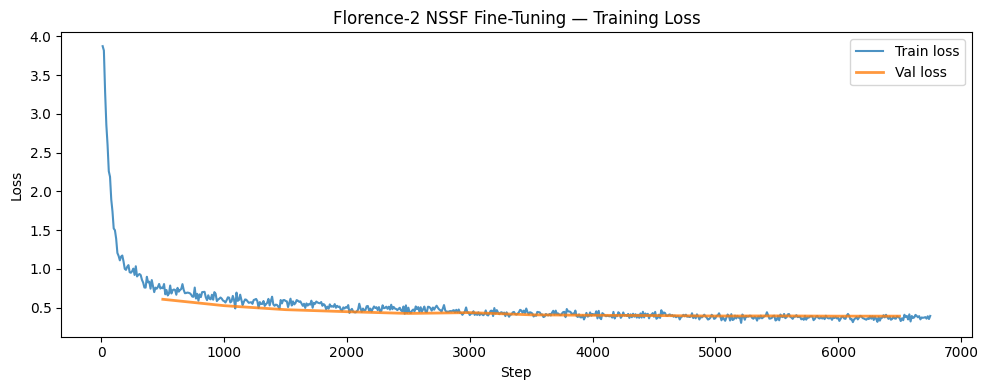

Loss curve saved → /workspace/training_loss.png
Interactive: https://wandb.ai/me/NSSF-Florence2-OCR


In [14]:
# Merge LoRA into base weights and save
# trainer.save_model() on a PEFT model saves only the adapter, not full weights.
# Loading it later causes a vocab size mismatch (51290 vs 51289) because
# AutoModelForCausalLM loads the original base before applying the adapter.
# Merging first creates a single self-contained model that loads cleanly.
print('Merging LoRA weights into base model…')
merged = trainer.model.merge_and_unload()
merged.config.vision_config.model_type = 'davit'
merged.save_pretrained(FINAL_MODEL)
processor.save_pretrained(FINAL_MODEL)
print(f'✅ Merged model saved → {FINAL_MODEL}')

# Loss curve (local backup — WandB has the interactive version)
try:
    import matplotlib.pyplot as plt
    log     = trainer.state.log_history
    steps_  = [e['step']      for e in log if 'loss'      in e]
    losses_ = [e['loss']      for e in log if 'loss'      in e]
    vsteps_ = [e['step']      for e in log if 'eval_loss' in e]
    vloss_  = [e['eval_loss'] for e in log if 'eval_loss' in e]

    plt.figure(figsize=(10, 4))
    plt.plot(steps_,  losses_, label='Train loss', alpha=0.8)
    plt.plot(vsteps_, vloss_,  label='Val loss',   alpha=0.8, lw=2)
    plt.xlabel('Step');  plt.ylabel('Loss')
    plt.title('Florence-2 NSSF Fine-Tuning — Training Loss')
    plt.legend();  plt.tight_layout()
    out_png = os.path.join(BASE_DIR, 'training_loss.png')
    plt.savefig(out_png, dpi=150);  plt.show()
    print(f'Loss curve saved → {out_png}')
    if USE_WANDB:
        print(f'Interactive: https://wandb.ai/{WANDB_ENTITY or "me"}/{WANDB_PROJECT}')
except Exception as e:
    print(f'Could not plot loss: {e}')


## 11. Evaluation — Exact Match, CER, Fuzzy Match
> **Run this cell after training finishes.**  
> Loads the saved final model fresh, runs on the validation split.


In [23]:
from peft import PeftConfig, PeftModel
from rapidfuzz.distance import Levenshtein
from rapidfuzz import fuzz

def load_eval_model(model_dir, device):
    """
    Load a fine-tuned Florence-2 model for evaluation.

    dtype fix: merge_and_unload() can leave mixed dtypes when the adapter
    has fp16 Conv2d weights (from LoRA on vision encoder layers). Calling
    .half() after the merge forces everything to fp16 consistently.
    The processor always outputs fp32 pixel_values; inference functions
    cast them to the model dtype before calling generate().
    """
    proc  = AutoProcessor.from_pretrained(model_dir, trust_remote_code=True)
    files = os.listdir(model_dir)

    if 'adapter_config.json' in files:
        print('  Detected PEFT adapter — loading base + merging…')
        peft_cfg  = PeftConfig.from_pretrained(model_dir)
        base_name = peft_cfg.base_model_name_or_path
        base = AutoModelForCausalLM.from_pretrained(
            base_name, trust_remote_code=True, torch_dtype=torch.float16,
        )
        base.resize_token_embeddings(len(proc.tokenizer))
        model = PeftModel.from_pretrained(base, model_dir).merge_and_unload()
        # Force uniform fp16 after merge — adapter Conv2d weights may be
        # stored in a different dtype, causing "Input type (float) and bias
        # type (c10::Half) should be the same" on the first forward pass.
        model = model.half()
    else:
        print(f'  Loading merged model…')
        # Load config first and enforce model_type = 'davit' before the model
        # is constructed — the assertion fires inside __init__ before weights
        # are even loaded, so patching config.json on disk beforehand is the
        # only reliable fix.
        from transformers import AutoConfig
        import json as _json, os as _os
        cfg_path = _os.path.join(model_dir, 'config.json')
        if _os.path.exists(cfg_path):
            cfg_data = _json.load(open(cfg_path))
            if cfg_data.get('vision_config', {}).get('model_type') != 'davit':
                cfg_data['vision_config']['model_type'] = 'davit'
                _json.dump(cfg_data, open(cfg_path, 'w'), indent=2)
                print(f'  ⚠ Fixed vision_config.model_type → davit in config.json')
        model = AutoModelForCausalLM.from_pretrained(
            model_dir, trust_remote_code=True, torch_dtype=torch.float16,
        )

    model = model.to(device).eval()
    print(f'  Model dtype : {next(model.parameters()).dtype}')
    return proc, model


print(f'Loading fine-tuned model from {FINAL_MODEL}…')
eval_proc, eval_model = load_eval_model(FINAL_MODEL, device)
print('✅ Model ready')

_MODEL_DTYPE = next(eval_model.parameters()).dtype


def normalize(v):
    return ' '.join(str(v).lower().split()) if v is not None else ''

def cer(ref, hyp):
    r, h = normalize(ref), normalize(hyp)
    if not r: return 0.0 if not h else 1.0
    return min(Levenshtein.distance(r, h) / len(r), 1.0)

def robust_parse(raw):
    """
    4-stage JSON recovery for Florence-2 OCR output.

    Stage 1 — standard json.loads() with key whitespace cleanup
    Stage 2 — fix trailing commas, bare string entries (keys without
               values like "Postal_Address_Box 35-50315"), control chars
    Stage 3 — truncation recovery: truncate at last complete key-value
               pair and close the object
    Stage 4 — regex salvage: extract all flat "Key": "Value" string
               pairs even when nested Table arrays are completely
               malformed; returns partial dict flagged with
               _table_parse_failed=True

    Why needed: table-heavy documents (Employer Returns, EFT forms)
    generate malformed JSON in the Table block. The old two-stage parser
    returned {} for these, scoring every field as 0. Stage 4 recovers
    Document_Type, Institution, Employer_Number etc. so flat fields
    contribute to the EM/CER scores.
    """
    raw = re.sub(r'<[^>]+>', '', raw).strip()
    if not raw:
        return {}

    def clean_keys(obj):
        """Strip leading/trailing spaces from all dict keys recursively.
        Handles model outputs like {" Employer_Number": "532061"}."""
        if isinstance(obj, dict):
            return {k.strip(): clean_keys(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [clean_keys(i) for i in obj]
        return obj

    # Stage 1: clean parse
    try:
        return clean_keys(json.loads(raw))
    except Exception:
        pass

    # Stage 2: fix common structural issues
    s2 = raw
    s2 = re.sub(r',\s*}', '}', s2)
    s2 = re.sub(r',\s*]', ']', s2)
    s2 = re.sub(r'[\x00-\x1f\x7f]', '', s2)
    # Remove bare string entries with no value:
    #   "Postal_Address_Box 35-50315",  →  removed
    s2 = re.sub(r',\s*"[^"]*"\s*(?=[,}])', '', s2)
    try:
        return clean_keys(json.loads(s2))
    except Exception:
        pass

    # Stage 3: truncation recovery
    # Find the last complete "key": "value" pair and close the object there
    last_complete = s2.rfind('",')
    if last_complete > 0:
        try:
            return clean_keys(json.loads(s2[:last_complete + 1] + '}'))
        except Exception:
            pass
    try:
        return clean_keys(json.loads(s2))
    except Exception:
        pass

    # Stage 4: regex salvage of all flat string pairs
    result = {}
    for m in re.finditer(r'"([^"]+)"\s*:\s*"([^"]*)"', raw):
        key = m.group(1).strip()
        val = m.group(2)
        if key:
            result[key] = val
    if result:
        result['_table_parse_failed'] = True
        return result

    return {}


def extract(item, num_beams=3):
    img = Image.open(os.path.join(IMAGE_BASE_DIR, item['images'][0])).convert('RGB')
    inp = eval_proc(text=TASK_TOKEN, images=img, return_tensors='pt').to(device)
    inp['pixel_values'] = inp['pixel_values'].to(_MODEL_DTYPE)
    with torch.no_grad():
        out = eval_model.generate(
            input_ids=inp['input_ids'],
            pixel_values=inp['pixel_values'],
            max_new_tokens=MAX_LABEL_LEN,
            num_beams=num_beams,
            early_stopping=True,
        )
    raw = eval_proc.batch_decode(out, skip_special_tokens=True)[0]
    return robust_parse(raw)


print(f'Evaluating on {len(val_records)} validation samples…')
all_em, all_cer, all_fuzzy = [], [], []
errors = []
_first_error_printed = False

for item in tqdm(val_records, desc='Eval'):
    try:
        gt   = json.loads(item['messages'][1]['content'])
        pred = extract(item)

        keys = set(gt) | set(pred)
        em_s = [1.0 if normalize(gt.get(k)) == normalize(pred.get(k)) else 0.0 for k in keys]
        c_s  = [cer(gt.get(k,''), pred.get(k,'')) for k in keys]
        f_s  = [fuzz.ratio(normalize(gt.get(k,'')), normalize(pred.get(k,''))) / 100 for k in keys]

        all_em.append(np.mean(em_s))
        all_cer.append(np.mean(c_s))
        all_fuzzy.append(np.mean(f_s))

        if np.mean(em_s) < 0.5:
            errors.append({'image': item['images'][0], 'gt': gt, 'pred': pred,
                           'em': np.mean(em_s), 'cer': np.mean(c_s)})
    except Exception as e:
        # Print the first exception in full so dtype / path errors are visible
        if not _first_error_printed:
            print(f'\n⚠ First exception: {type(e).__name__}: {e}')
            _first_error_printed = True
        errors.append({'image': item['images'][0], 'error': f'{type(e).__name__}: {e}'})

bar = '=' * 46
print(f'\n{bar}')
if all_em:
    print(f'  Exact Match  : {np.mean(all_em):.3f}')
    print(f'  CER          : {np.mean(all_cer):.3f}')
    print(f'  Fuzzy Match  : {np.mean(all_fuzzy):.3f}')
else:
    print('  No successful predictions — check the first exception above')
print(f'  Exceptions   : {sum(1 for e in errors if "error" in e)} / {len(val_records)}')
print(f'  Low-EM (<0.5): {sum(1 for e in errors if "em" in e)} / {len(val_records)}')
print(bar)


Loading fine-tuned model from /workspace/florence2-nssf-ocr-final…
  Loading merged model…
  Model dtype : torch.float16
✅ Model ready
Evaluating on 406 validation samples…


Eval:   0%|          | 0/406 [00:00<?, ?it/s]


  Exact Match  : 0.255
  CER          : 0.636
  Fuzzy Match  : 0.392
  Exceptions   : 0 / 406
  Low-EM (<0.5): 364 / 406


## 12. Error Analysis

In [26]:
from collections import Counter

# ── Failure breakdown by document type ───────────────────────────────────────
failed_types = []
for e in errors:
    if 'gt' in e:
        failed_types.append(e['gt'].get('Document_Type', 'UNKNOWN'))
    else:
        failed_types.append('EXCEPTION')

print('Failures by Document_Type:')
for dt, cnt in Counter(failed_types).most_common(15):
    bar_len = int(cnt / max(Counter(failed_types).values()) * 30)
    print(f'  {dt:<50} {cnt:>3}  {"█" * bar_len}')

# ── Worst 5 samples ───────────────────────────────────────────────────────────
print()
worst = sorted([e for e in errors if 'em' in e], key=lambda e: e['em'])[:5]
for i, err in enumerate(worst, 1):
    print(f'[{i}] {err["image"]}  EM={err["em"]:.2f}  CER={err["cer"]:.2f}')
    gt_str   = json.dumps(err['gt'],   indent=2, ensure_ascii=False)
    pred_str = json.dumps(err['pred'], indent=2, ensure_ascii=False)
    print(f'  GT  : {gt_str[:250]}')
    print(f'  PRED: {pred_str[:250]}')
    print()

Failures by Document_Type:
  Correspondence Letter                               29  ██████████████████████████████
  UNKNOWN                                             26  ██████████████████████████
  FINGERPRINT FORM                                    22  ██████████████████████
  Payment Receipt                                     20  ████████████████████
  CERTIFICATE OF IDENTITY (B)                         19  ███████████████████
  Local Administration Letter                         19  ███████████████████
  Correspondence_letter                               17  █████████████████
  Fingerprint Form                                    16  ████████████████
  Provisional Member Statement of Account             16  ████████████████
  Membership Card                                     15  ███████████████
  ELECTRONIC FUNDS TRANSFER (EFT) FORM                15  ███████████████
  CONTRIBUTIONS NOT REFLECTED IN MEMBER'S ACCOUNT EXTRACTED FROM EMPLOYER RETURNS  14  ██████████████
  Certi

## 13. Throughput Benchmark (Target: ≥ 1200 docs/hour)

In [27]:
BENCH_N  = 50
BENCH_BS = 8


def batch_extract(items, batch_size=BENCH_BS, num_beams=3):
    """Batched Florence-2 inference."""
    preds = []
    _dtype = next(eval_model.parameters()).dtype   # model's actual dtype

    for i in range(0, len(items), batch_size):
        chunk   = items[i:i+batch_size]
        images  = [Image.open(os.path.join(IMAGE_BASE_DIR, it['images'][0])).convert('RGB')
                   for it in chunk]
        prompts = [TASK_TOKEN] * len(images)

        inp = eval_proc(
            text=prompts, images=images, return_tensors='pt', padding=True
        ).to(device)
        # Cast pixel_values to model dtype — processor always returns fp32,
        # but model Conv2d weights are fp16 after merge → dtype mismatch crash
        inp['pixel_values'] = inp['pixel_values'].to(_dtype)

        with torch.no_grad():
            out = eval_model.generate(
                input_ids=inp['input_ids'],
                pixel_values=inp['pixel_values'],
                # attention_mask intentionally omitted —
                # Florence-2 rebuilds it after image/text merge
                max_new_tokens=MAX_LABEL_LEN,
                num_beams=num_beams,
            )
        for raw in eval_proc.batch_decode(out, skip_special_tokens=True):
            raw = re.sub(r'<[^>]+>', '', raw).strip()
            try:    preds.append(json.loads(raw))
            except: preds.append({})
    return preds


bench = random.sample(raw_data, BENCH_N)
print(f'Benchmarking on {BENCH_N} images (batch_size={BENCH_BS}, num_beams=3)…')

t0      = time.time()
_       = batch_extract(bench)
elapsed = time.time() - t0
s_per   = elapsed / BENCH_N
d_hour  = 3600 / s_per
TARGET  = 1200

print(f'\n  Total time   : {elapsed:.1f}s')
print(f'  Sec / image  : {s_per:.2f}s  (target ≤ 3.0s)')
print(f'  Docs / hour  : {d_hour:.0f}  (target ≥ {TARGET})')
print(f'  {"✅ TARGET MET" if d_hour >= TARGET else "⚠  BELOW TARGET — see tips below"}')

if d_hour < TARGET:
    print('\n  Tuning tips:')
    print('   • Try batch_size 16 — biggest single win if VRAM allows')
    print('   • Confirm num_beams=3 (not higher)')
    print('   • torch.compile(eval_model) on PyTorch 2.0+ for ~15% speedup')
    print('   • Quantise to 4-bit with bitsandbytes for ~2x memory reduction')

Benchmarking on 50 images (batch_size=8, num_beams=3)…

  Total time   : 22.5s
  Sec / image  : 0.45s  (target ≤ 3.0s)
  Docs / hour  : 7985  (target ≥ 1200)
  ✅ TARGET MET


## 14. Production Inference Snippet
Drop this into your extraction service:

```python
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch, json, re

MODEL_PATH = 'florence2-nssf-ocr-final'   # path on your RunPod / server
TASK_TOKEN = '<Extract_NSSF_Data>'

processor = AutoProcessor.from_pretrained(MODEL_PATH, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, trust_remote_code=True, torch_dtype=torch.float16
).to('cuda').eval()

def extract_fields(image_path: str) -> dict:
    image  = Image.open(image_path).convert('RGB')
    inputs = processor(
        text=TASK_TOKEN, images=image, return_tensors='pt'
    ).to('cuda')
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=512, num_beams=3)
    raw = processor.batch_decode(out, skip_special_tokens=True)[0]
    raw = re.sub(r'<[^>]+>', '', raw).strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {'_raw': raw}   # return raw text if JSON parse fails
```

### Interpreting Results

| Metric | Excellent | Acceptable | Needs Work |
|--------|-----------|------------|------------|
| Exact Match | > 0.80 | 0.60–0.80 | < 0.60 |
| CER | < 0.05 | 0.05–0.15 | > 0.15 |
| Fuzzy Match | > 0.90 | 0.75–0.90 | < 0.75 |

### If CER is high on handwriting
- Increase `NUM_EPOCHS` to 7–10
- Use stronger augmentation (higher blur / brightness range)
- Check if ground-truth abbreviations are consistent (e.g. `KIS.K.MU.` vs `KISKMU`)

### If tables (`Table` field) score low
- Confirm table ground truth format is consistent across all 2,675 entries
- Consider a dedicated `<Extract_NSSF_Table>` task token fine-tuned separately

### If still OOM after all fixes
```python
BATCH_SIZE = 1
GRAD_ACCUM = 8   # same effective batch of 8
# Also switch to florence-2-large (not base-ft) — slightly smaller
```
